In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import normaltest
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
import gseapy as gp

In [2]:
expr_path  = "OmicsExpressionProteinCodingGenesTPMlogp1BatchCorrected.csv"
prism_path = "prism-repurposing-20q2-secondary-screen-dose-response-curve-parameters.csv"

expr = pd.read_csv(expr_path)
expr = expr.rename(columns={expr.columns[0]: "depmap_id"})
prism = pd.read_csv(prism_path)

C:\Users\6767n\AppData\Local\Temp\ipykernel_53232\1092779390.py:6: DtypeWarning: Columns (16,17) have mixed types. Specify dtype option on import or set low_memory=False.
  prism = pd.read_csv(prism_path)


In [3]:
prism.head()

,broad_id,depmap_id,ccle_name,screen_id,upper_limit,lower_limit,slope,r2,auc,ec50,ic50,passed_str_profiling,row_name,name,moa,target,disease.area,indication,smiles,phase
0,BRD-K36949735-001-01-1,ACH-000948,2313287_STOMACH,MTS010,1.088523,-1.079841,8.284451,0.913068,0.989373,10.375348,9.209687,True,PR500_ACH-000948,anlotinib,"VEGFR inhibitor, PDGFR tyrosine kinase recepto...","KDR, PDGFRB",NaN,NaN,COc1cc2c(Oc3ccc4[nH]c(C)cc4c3F)ccnc2cc1OCC1(N)CC1,Phase 2/Phase 3
1,BRD-K36949735-001-01-1,ACH-000011,253J_URINARY_TRACT,MTS010,1.004565,-2.248875,7.883544,0.934277,0.988011,11.475826,9.255366,True,PR500_ACH-000011,anlotinib,"VEGFR inhibitor, PDGFR tyrosine kinase recepto...","KDR, PDGFRB",NaN,NaN,COc1cc2c(Oc3ccc4[nH]c(C)cc4c3F)ccnc2cc1OCC1(N)CC1,Phase 2/Phase 3
2,BRD-K36949735-001-01-1,ACH-000026,253JBV_URINARY_TRACT,MTS010,1.068269,-21.457752,1.216485,0.877853,0.958743,167.921713,8.327173,True,PR500_ACH-000026,anlotinib,"VEGFR inhibitor, PDGFR tyrosine kinase recepto...","KDR, PDGFRB",NaN,NaN,COc1cc2c(Oc3ccc4[nH]c(C)cc4c3F)ccnc2cc1OCC1(N)CC1,Phase 2/Phase 3
3,BRD-K36949735-001-01-1,ACH-000323,42MGBA_CENTRAL_NERVOUS_SYSTEM,MTS010,0.985761,0.029825,0.929279,0.929666,0.814224,2.221636,2.300992,True,PR500_ACH-000323,anlotinib,"VEGFR inhibitor, PDGFR tyrosine kinase recepto...","KDR, PDGFRB",NaN,NaN,COc1cc2c(Oc3ccc4[nH]c(C)cc4c3F)ccnc2cc1OCC1(N)CC1,Phase 2/Phase 3
4,BRD-K36949735-001-01-1,ACH-000905,5637_URINARY_TRACT,MTS010,1.129441,0.017405,1.158793,0.929414,0.830589,1.459074,1.835021,True,PR500_ACH-000905,anlotinib,"VEGFR inhibitor, PDGFR tyrosine kinase recepto...","KDR, PDGFRB",NaN,NaN,COc1cc2c(Oc3ccc4[nH]c(C)cc4c3F)ccnc2cc1OCC1(N)CC1,Phase 2/Phase 3


In [4]:
expr.head()

,depmap_id,TFE3 (7030),MMADHC (27249),PABPC1L (80336),RELL2 (285613),GPT (2875),GUSB (2990),H4-16 (121504),DDB2 (1643),RPS4X (6191),...,OR2A42 (402317),HOXB7 (3217),NSA2 (10412),UGT2B11 (10720),ZNF747 (65988),NAA60 (79903),MYH4 (4622),MTAP (4507),C14orf93 (60686),NR3C2 (4306)
0,ACH-000873,3.607691,3.531071,4.982285,2.326016,0.607679,5.118549,1.282028,4.512297,10.075438,...,0.042564,3.870581,5.178480,-0.007723,2.005498,4.213717,-0.001724,3.904800,2.190931,0.203910
1,ACH-000860,4.192566,6.865682,4.853288,2.725583,0.197016,5.666426,1.154470,4.306808,10.215240,...,0.031621,-0.005897,6.749713,-0.007723,1.393644,4.334535,-0.001724,4.812949,3.366939,0.370726
2,ACH-000439,3.265517,5.804615,1.777636,4.185835,0.389025,6.593342,0.410244,4.411381,11.644890,...,-0.013226,-0.033868,6.877322,1.596383,3.143557,4.624226,-0.001724,4.122929,2.197136,0.015412
3,ACH-000318,3.705500,5.813170,4.536005,2.290409,0.471169,5.160089,2.325673,5.017968,9.163992,...,-0.013226,3.051092,5.610027,-0.007723,2.334419,3.881219,-0.001724,0.394778,3.217293,0.277760
4,ACH-001142,6.105227,7.051513,4.457555,2.543055,0.022363,4.589966,2.369987,4.105131,10.179188,...,0.053402,3.582671,7.416571,-0.007723,2.294077,4.889203,-0.001724,4.379944,2.355443,0.520338


In [5]:
initial_rows = prism.shape[0]

prism_filtered = prism[
    (prism['auc'].notna()) &
    (prism['r2'] >= 0.8) &
    (prism['auc'] >= 0.0)
].copy()

filtered_prism_rows = prism_filtered.shape[0]

print(f'prism rows before filter: {initial_rows}')
print(f'prism rows after filter: {filtered_prism_rows}')
print(f'{initial_rows - filtered_prism_rows} rows removed')

prism rows before filter: 753778
prism rows after filter: 104944
648834 rows removed


In [6]:
# 2. Statistical Distribution Check (D'Agostino's K-squared test)
stat, p_value = normaltest(prism_filtered['auc'])

stat, p_value

(np.float64(4251.204538077198), np.float64(0.0))

In [7]:
if p_value < 0.05:
    print(f'p-value = {p_value:.4e} The AUC data is significantly skewed (Not normally distributed).')
else:
    print(f'p-value = {p_value:.4e} The AUC data follows a roughly normal distribution.')

p-value = 0.0000e+00 The AUC data is significantly skewed (Not normally distributed).


In [8]:
# I will apply log2() on the 'AUC'
#Adding a samll constent to avoid log(0) errors
prism_filtered['log2_auc'] = np.log2(prism_filtered['auc'] + 1e-6)

In [9]:
prism_filtered['log2_auc'].describe()

count    104944.000000
mean         -0.658728
std           0.567438
min          -7.704391
25%          -0.882518
50%          -0.511917
75%          -0.274209
max           1.672264
Name: log2_auc, dtype: float64

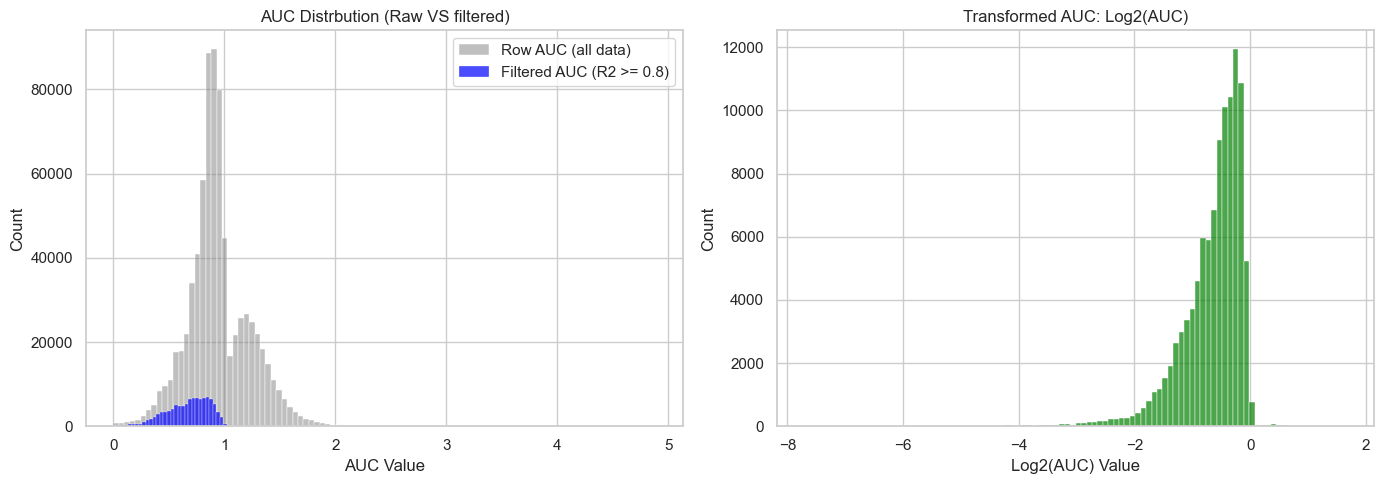

In [10]:
sns.set_theme(style='whitegrid')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(prism['auc'].dropna(), bins=100, ax=axes[0], color='gray', alpha=0.5, label= 'Row AUC (all data)')
sns.histplot(prism_filtered['auc'], bins=100, ax=axes[0], color='blue', alpha= 0.7, label= 'Filtered AUC (R2 >= 0.8)')
axes[0].set_title('AUC Distrbution (Raw VS filtered)')
axes[0].set_xlabel('AUC Value')
axes[0].legend()

sns.histplot(prism_filtered['log2_auc'], bins=100, ax=axes[1], color='green', alpha= 0.7)
axes[1].set_title('Transformed AUC: Log2(AUC)')
axes[1].set_xlabel('Log2(AUC) Value')

plt.tight_layout()
plt.show()

In [11]:


# 1. SMILES Cleaning Function
def clean_smiles(s):
    if pd.isna(s) or not isinstance(s, str):
        return ""
    
    s = s.strip()
    
    # Some drugs come as a mixture separated by commas; we take the primary compound
    if "," in s:
        s = s.split(",")[0].strip() 
    
    # Filter out invalid SMILES characters
    allowed_chars = "ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz0123456789[]()=#@+-/\\."
    s = "".join(ch for ch in s if ch in allowed_chars)
    
    return s

# 2. Morgan Fingerprint Generation Function
def smiles_to_morgan_fp(smiles, n_bits=256):
    smiles = clean_smiles(smiles)
    if not smiles:
        return np.zeros(n_bits)
    
    mol = Chem.MolFromSmiles(smiles)
    if mol is None: 
        return np.zeros(n_bits)
    
    # Using the new MorganGenerator as requested by RDKit
    mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=n_bits)
    fp = mfpgen.GetFingerprintAsNumPy(mol)
    
    return fp

# 3. Build Drug Features DataFrame
# Assuming the filtered data from Step 1 is named 'prism_filtered'
print("Extracting unique drugs...")
unique_drugs = prism_filtered[['broad_id', 'smiles']].drop_duplicates().reset_index(drop=True)

# Compute fingerprints for all unique drugs
print("Computing Morgan Fingerprints...")
fps = np.vstack([smiles_to_morgan_fp(s) for s in unique_drugs['smiles']])

# Create feature column names (fp_0, fp_1, ... fp_255)
fp_cols = [f"fp_{i}" for i in range(fps.shape[1])]
fps_df = pd.DataFrame(fps, columns=fp_cols)

# Concatenate drug IDs with their respective fingerprints
drug_features_df = pd.concat([unique_drugs[['broad_id']].reset_index(drop=True), fps_df], axis=1)

print("\n=== Drug Features Pipeline Report ===")
print("Successfully built the drug features DataFrame.")
print(f"Number of unique drugs processed: {drug_features_df.shape[0]}")
print(f"Number of chemical features (bits) per drug: {fps.shape[1]}")

Extracting unique drugs...
Computing Morgan Fingerprints...

=== Drug Features Pipeline Report ===
Successfully built the drug features DataFrame.
Number of unique drugs processed: 1182
Number of chemical features (bits) per drug: 256


In [12]:
# 1. Prepare Gene Expression Data for ssGSEA
print("Preparing gene expression data for ssGSEA...")

# Create a working copy of the expression data
expr_for_ssgsea = expr.copy()

# Extract depmap_id to be used later as column headers (samples)
cell_ids = expr_for_ssgsea['depmap_id']

# Drop the ID column and clean gene symbols by removing trailing Ensembl IDs (e.g., "(123)")
expr_for_ssgsea = expr_for_ssgsea.drop(columns=["depmap_id"])
expr_for_ssgsea.columns = expr_for_ssgsea.columns.str.replace(r"\s*\(\d+\)", "", regex=True)

# Transpose the DataFrame: gseapy requires Genes as the index (rows) and Samples as columns
expr_T = expr_for_ssgsea.T
expr_T.columns = cell_ids.values

# 2. Run ssGSEA Algorithm
print("Running ssGSEA with KEGG_2021_Human. This process calculates enrichment scores per cell line...")

ssgsea_res = gp.ssgsea(
    data=expr_T,
    gene_sets="KEGG_2021_Human",
    outdir=None,                 # Store results in memory rather than saving to disk
    sample_norm_method='rank',   # Apply rank normalization (standard for ssGSEA)
    no_plot=True                 # Disable individual pathway plotting for computational efficiency
)

# 3. Process the Results for Machine Learning Integration
print("Processing ssGSEA results for XGBoost...")

res_df = ssgsea_res.res2d.copy()

# Pivot the dataframe to transform from long format to wide format.
# This maps Cell Lines (Name) to rows and Pathways (Term) to columns, populated by NES values.
pathway_expr_ssgsea = res_df.pivot(index='Name', columns='Term', values='NES')

# Reset the index to convert the cell line IDs back into a standard column
pathway_expr_ssgsea = pathway_expr_ssgsea.reset_index()
pathway_expr_ssgsea = pathway_expr_ssgsea.rename(columns={'Name': 'depmap_id'})

# Standardize pathway column names: remove suffixes, replace spaces with underscores, and convert to lowercase
pathway_expr_ssgsea.columns = [
    str(col).split(" - Homo")[0].replace(" ", "_").lower() if col != 'depmap_id' else col 
    for col in pathway_expr_ssgsea.columns
]

print("\n=== Cell Line Features (ssGSEA) Report ===")
print("Successfully built the Cell Line Features DataFrame.")
print(f"Number of cell lines processed: {pathway_expr_ssgsea.shape[0]}")
print(f"Number of engineered pathway features (NES): {pathway_expr_ssgsea.shape[1] - 1}")

# Display the first 5 rows to verify structure
pathway_expr_ssgsea.head()

Preparing gene expression data for ssGSEA...
Running ssGSEA with KEGG_2021_Human. This process calculates enrichment scores per cell line...
Processing ssGSEA results for XGBoost...

=== Cell Line Features (ssGSEA) Report ===
Successfully built the Cell Line Features DataFrame.
Number of cell lines processed: 1673
Number of engineered pathway features (NES): 306


,depmap_id,abc_transporters,age-rage_signaling_pathway_in_diabetic_complications,ampk_signaling_pathway,acute_myeloid_leukemia,adherens_junction,adipocytokine_signaling_pathway,adrenergic_signaling_in_cardiomyocytes,african_trypanosomiasis,"alanine,_aspartate_and_glutamate_metabolism",...,vitamin_digestion_and_absorption,wnt_signaling_pathway,yersinia_infection,alpha-linolenic_acid_metabolism,beta-alanine_metabolism,camp_signaling_pathway,cgmp-pkg_signaling_pathway,mrna_surveillance_pathway,mtor_signaling_pathway,p53_signaling_pathway
0,ACH-000001,-0.095592,0.126447,0.195821,0.157864,0.279448,0.132743,0.067346,-0.098043,0.102279,...,-0.070201,0.089254,0.197136,-0.115445,0.048164,0.011427,0.057114,0.306965,0.196366,0.242102
1,ACH-000002,-0.040889,0.137719,0.167659,0.244375,0.149597,0.1286,0.03615,-0.052397,0.107626,...,-0.039154,0.033586,0.237664,-0.091248,0.049903,-0.02641,0.041165,0.316996,0.176646,0.240097
2,ACH-000003,0.045959,0.143124,0.192297,0.174913,0.292482,0.11485,0.062463,-0.048298,0.159458,...,0.119355,0.07711,0.194644,-0.039152,0.122601,0.003136,0.065261,0.314373,0.195397,0.238583
3,ACH-000004,0.017592,0.125253,0.182363,0.228396,0.191302,0.173771,0.0759,0.018595,0.132493,...,-0.078086,0.061425,0.232473,-0.073341,0.047554,0.005555,0.087517,0.307209,0.177975,0.213497
4,ACH-000005,-0.005379,0.12401,0.190382,0.225785,0.205654,0.163224,0.065699,0.011086,0.124631,...,-0.065544,0.061204,0.239034,-0.091476,0.04083,-0.003491,0.08768,0.315893,0.172826,0.226788


In [13]:
# ==========================================
# Final Dataset Merge (Features + Target)
# ==========================================
print("Starting Final Data Merge...")

# 1. Start with the base DataFrame (IDs and the cleaned Target)
base_df = prism_filtered[['depmap_id', 'broad_id', 'log2_auc', 'auc']].copy()

# 2. Merge Biological Features (ssGSEA Enrichment Scores)
# 'inner' join ensures we only keep cell lines that exist in both PRISM and our processed RNA-seq data
merged_df = base_df.merge(pathway_expr_ssgsea, on='depmap_id', how='inner')
print(f"Shape after merging biological features: {merged_df.shape}")

# 3. Merge Chemical Features (Morgan Fingerprints)
# 'inner' join ensures we only keep drugs that have valid SMILES and successfully generated fingerprints
final_dataset = merged_df.merge(drug_features_df, on='broad_id', how='inner')

# 4. Final Cleanup: Drop any accidental missing values to be 100% safe for future modeling
final_dataset = final_dataset.dropna().reset_index(drop=True)

print("\n=== Final Dataset Report ===")
print(f"Final Dataset Shape: {final_dataset.shape} (Rows: cell-drug pairs, Columns: Features + Target)")
print(f"Total Input Features (X) available for the model: {final_dataset.shape[1] - 3}") 


# Display the first 5 rows to inspect the final structure
final_dataset.head()

Starting Final Data Merge...
Shape after merging biological features: (103050, 310)

=== Final Dataset Report ===
Final Dataset Shape: (103050, 566) (Rows: cell-drug pairs, Columns: Features + Target)
Total Input Features (X) available for the model: 563


,depmap_id,broad_id,log2_auc,auc,abc_transporters,age-rage_signaling_pathway_in_diabetic_complications,ampk_signaling_pathway,acute_myeloid_leukemia,adherens_junction,adipocytokine_signaling_pathway,...,fp_246,fp_247,fp_248,fp_249,fp_250,fp_251,fp_252,fp_253,fp_254,fp_255
0,ACH-000948,BRD-K36949735-001-01-1,-0.015412,0.989373,0.017552,0.127209,0.214541,0.167233,0.261166,0.14994,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,ACH-000011,BRD-K36949735-001-01-1,-0.017400,0.988011,0.005193,0.171346,0.179407,0.146097,0.267871,0.139898,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,ACH-000026,BRD-K36949735-001-01-1,-0.060783,0.958743,-0.006904,0.143067,0.179742,0.178845,0.263235,0.147797,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,ACH-000323,BRD-K36949735-001-01-1,-0.296500,0.814224,-0.069897,0.20268,0.198764,0.167577,0.273982,0.136718,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,ACH-000905,BRD-K36949735-001-01-1,-0.267791,0.830589,-0.072752,0.214098,0.186072,0.218054,0.319719,0.130219,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
#Save dataset to a CSV file 
final_dataset.to_csv("PRISM_DepMap_Final_Processed_Dataset.csv", index=False)
print("Dataset saved successfully to CSV.")

Dataset saved successfully to CSV.
